In [ ]:
import os
import sys
import csv
import numpy as np

# Make sure repo root is on sys.path
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from deep_sdf import metrics
import deep_sdf.workspace as ws

# --- Paths (edit as needed) ---
experiment_dir = os.path.join(repo_root, 'examples', 'ADNI_1_L_No_MCI', 'minimal_eikonal_256D_no_lambda')
gt_mesh_dir = '/home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files'
gt_ext = '.obj'

train_recon_dir = os.path.join(experiment_dir, ws.tb_logs_dir, ws.tb_logs_train_reconstructions)
out_csv = os.path.join(experiment_dir, 'train_recon_chamfer.csv')

print('train_recon_dir:', train_recon_dir)
print('gt_mesh_dir:', gt_mesh_dir)


train_recon_dir: /home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI/minimal_eikonal_cov_256D_no_lambda/TensorBoard/ReconstructionsTrain
gt_mesh_dir: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/minimal_scaled_obj_files


In [4]:
import glob

mesh_paths = sorted(glob.glob(os.path.join(train_recon_dir, '*', '*.ply')))
if not mesh_paths:
    mesh_paths = sorted(glob.glob(os.path.join(train_recon_dir, '*', '*.obj')))

rows = []
cd_vals = []

for mesh_path in mesh_paths:
    shape_name = os.path.basename(os.path.dirname(mesh_path))
    gt_path = os.path.join(gt_mesh_dir, shape_name + gt_ext)
    mesh_name = os.path.basename(mesh_path)

    if not os.path.isfile(gt_path):
        rows.append((shape_name, mesh_name, 'n/a', 'missing_gt'))
        print(f'{shape_name} {mesh_name} chamfer=n/a (missing_gt)')
        continue

    try:
        cd, _ = metrics.compute_metric(gt_mesh=gt_path, gen_mesh=mesh_path, metric='chamfer')
        cd_val = float(cd)
        rows.append((shape_name, mesh_name, cd_val, 'ok'))
        cd_vals.append(cd_val)
        print(f'{shape_name} {mesh_name} chamfer={cd_val:.6f}')
    except Exception as exc:
        rows.append((shape_name, mesh_name, 'n/a', f'error:{type(exc).__name__}'))
        print(f'{shape_name} {mesh_name} chamfer=n/a ({type(exc).__name__})')

with open(out_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['shape', 'mesh_file', 'chamfer', 'status'])
    writer.writerows(rows)

if cd_vals:
    print('Mean Chamfer:', float(np.mean(cd_vals)))
else:
    print('No Chamfer computed.')

print('Meshes processed:', len(mesh_paths))
print('Saved CSV:', out_csv)


ADNI_005_S_1341_MR_Hippocampal_Mask_Hi_20090630140708759_S48768_I146918_left epoch=1200.ply chamfer=0.001189
ADNI_005_S_1341_MR_Hippocampal_Mask_Hi_20090630140708759_S48768_I146918_left epoch=1500.ply chamfer=0.001212
ADNI_005_S_1341_MR_Hippocampal_Mask_Hi_20090630140708759_S48768_I146918_left epoch=1800.ply chamfer=0.001224
ADNI_005_S_1341_MR_Hippocampal_Mask_Hi_20090630140708759_S48768_I146918_left epoch=300.ply chamfer=0.001343
ADNI_005_S_1341_MR_Hippocampal_Mask_Hi_20090630140708759_S48768_I146918_left epoch=600.ply chamfer=0.001140
ADNI_005_S_1341_MR_Hippocampal_Mask_Hi_20090630140708759_S48768_I146918_left epoch=900.ply chamfer=0.001301
ADNI_007_S_1206_MR_Hippocampal_Mask_Hi_20090630141923607_S25703_I146935_left epoch=1200.ply chamfer=0.000559
ADNI_007_S_1206_MR_Hippocampal_Mask_Hi_20090630141923607_S25703_I146935_left epoch=1500.ply chamfer=0.000565
ADNI_007_S_1206_MR_Hippocampal_Mask_Hi_20090630141923607_S25703_I146935_left epoch=1800.ply chamfer=0.000557
ADNI_007_S_1206_MR_Hip

train latents: (696, 256) test latents: (77, 256)
train labels valid: 696 test labels valid: 77
Mean L2 distance (train vs test): 0.26471495628356934
KS mean/median: 0.1902161236751754 0.1794764143902075
PCA explained variance: [0.05827308 0.04786064]


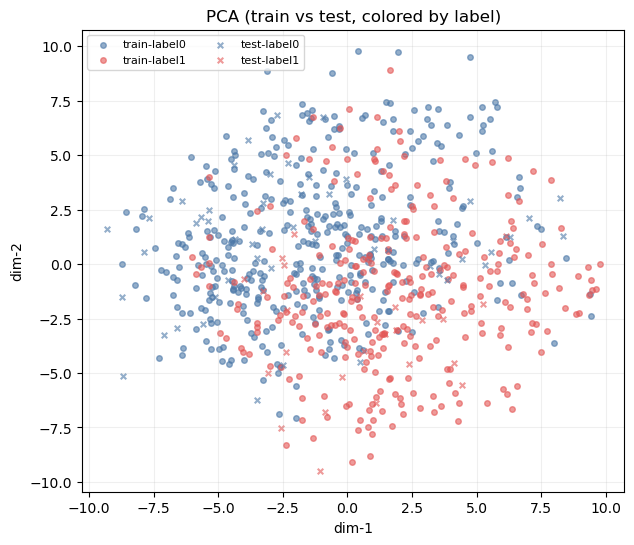

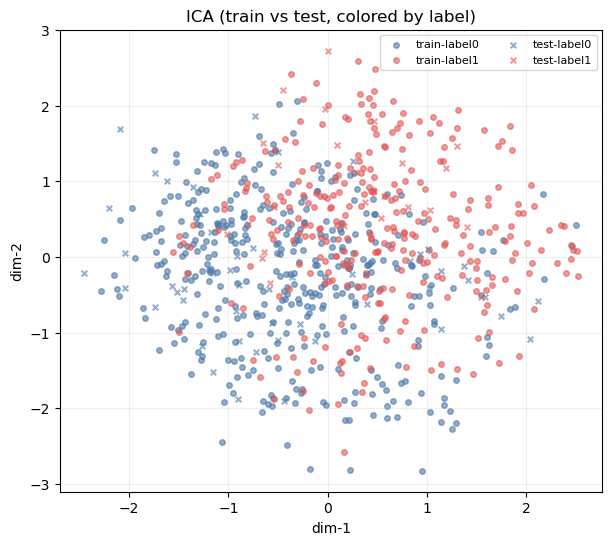

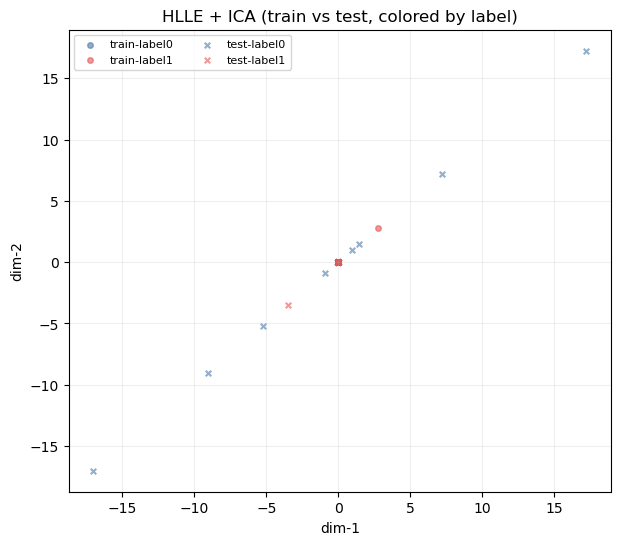

KMeans silhouette: 0.03746912
KMeans train: ARI=0.1653, best_acc=0.7040
KMeans test: ARI=0.1108, best_acc=0.6753


In [14]:
import json
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

specs = ws.load_experiment_specifications(experiment_dir)
data_source = specs['DataSource']
train_split_file = specs['TrainSplit']
test_split_file = specs['TestSplit']

def _resolve_split_path(p):
    if os.path.isabs(p):
        return p
    candidate = os.path.join(repo_root, p)
    return candidate if os.path.exists(candidate) else p

train_split_file = _resolve_split_path(train_split_file)
test_split_file = _resolve_split_path(test_split_file)
labels_path = os.path.join(data_source, 'labels.pt')

train_latents_path = os.path.join(experiment_dir, 'LatentCodes', 'latest.pth')
test_latents_path = os.path.join(experiment_dir, 'test_latents', 'test_latents.pt')
label_index = 0  # diagnosis

def _base_name(p):
    return os.path.splitext(os.path.basename(p))[0]

def _load_latent_codes(path):
    data = torch.load(path, map_location='cpu')
    if isinstance(data, dict) and 'latent_codes' in data:
        lat = data['latent_codes']
        if isinstance(lat, torch.Tensor):
            if lat.dim() == 3:
                lat = lat.squeeze(1)
            return lat
        if isinstance(lat, dict) and 'weight' in lat:
            return torch.as_tensor(lat['weight'])
    if isinstance(data, dict):
        # dict of name -> latent
        return {k: v for k, v in data.items()}
    raise ValueError('Unsupported latent format')

def _collect_labels(names, label_map, index):
    labels = []
    for name in names:
        lbl = label_map.get(name)
        if lbl is None:
            labels.append(float('nan'))
            continue
        if isinstance(lbl, torch.Tensor):
            lbl = lbl.detach().cpu().numpy()
        labels.append(float(lbl[index]))
    return np.array(labels, dtype=float)

with open(train_split_file) as f:
    train_split = json.load(f)
with open(test_split_file) as f:
    test_split = json.load(f)

train_names = [_base_name(p) for p in train_split]
test_names = [_base_name(p) for p in test_split]

label_map = torch.load(labels_path)

train_latents_raw = _load_latent_codes(train_latents_path)
test_latents_raw = _load_latent_codes(test_latents_path)

if isinstance(train_latents_raw, dict):
    train_latents = []
    train_keep = []
    for name in train_names:
        if name in train_latents_raw:
            train_latents.append(train_latents_raw[name].detach().cpu())
            train_keep.append(name)
    train_latents = torch.stack(train_latents, dim=0) if train_latents else torch.empty((0, 1))
    train_names = train_keep
else:
    train_latents = train_latents_raw
    if train_latents.shape[0] > len(train_names):
        train_latents = train_latents[: len(train_names)]

if isinstance(test_latents_raw, dict):
    test_latents = []
    test_keep = []
    for name in test_names:
        if name in test_latents_raw:
            test_latents.append(test_latents_raw[name].detach().cpu())
            test_keep.append(name)
    test_latents = torch.stack(test_latents, dim=0) if test_latents else torch.empty((0, 1))
    test_names = test_keep
else:
    test_latents = test_latents_raw
    if test_latents.shape[0] > len(test_names):
        test_latents = test_latents[: len(test_names)]

train_latents = train_latents.cpu().numpy()
test_latents = test_latents.cpu().numpy()

def _squeeze_latents(arr):
    if arr.ndim == 3 and arr.shape[1] == 1:
        return arr[:, 0, :]
    if arr.ndim == 3 and arr.shape[2] == 1:
        return arr[:, :, 0]
    return arr

train_latents = _squeeze_latents(train_latents)
test_latents = _squeeze_latents(test_latents)

train_labels = _collect_labels(train_names, label_map, label_index)
test_labels = _collect_labels(test_names, label_map, label_index)

print('train latents:', train_latents.shape, 'test latents:', test_latents.shape)
print('train labels valid:', np.isfinite(train_labels).sum(), 'test labels valid:', np.isfinite(test_labels).sum())

if train_latents.shape[1] != test_latents.shape[1]:
    raise ValueError('Latent dims differ: train={} test={}'.format(train_latents.shape[1], test_latents.shape[1]))

all_latents = np.vstack([train_latents, test_latents])
split_flags = np.array(['train'] * len(train_latents) + ['test'] * len(test_latents))
all_labels = np.concatenate([train_labels, test_labels])

scaler = StandardScaler()
all_latents_z = scaler.fit_transform(all_latents)

mean_train = np.mean(train_latents, axis=0)
mean_test = np.mean(test_latents, axis=0)
mean_diff = np.linalg.norm(mean_train - mean_test)

ks_stats = []
for d in range(train_latents.shape[1]):
    ks_stats.append(ks_2samp(train_latents[:, d], test_latents[:, d]).statistic)

print('Mean L2 distance (train vs test):', float(mean_diff))
print('KS mean/median:', float(np.mean(ks_stats)), float(np.median(ks_stats)))

def _plot_2d(emb, title):
    plt.figure(figsize=(7, 6))
    for split, marker in [('train', 'o'), ('test', 'x')]:
        for lbl, color in [(0, '#4C78A8'), (1, '#E45756')]:
            mask = (split_flags == split) & (all_labels == lbl)
            if mask.any():
                plt.scatter(emb[mask, 0], emb[mask, 1], s=16, alpha=0.6, c=color, marker=marker, label=f'{split}-label{lbl}')
    plt.title(title)
    plt.xlabel('dim-1')
    plt.ylabel('dim-2')
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.2)
    plt.show()

pca = PCA(n_components=2)
pca_emb = pca.fit_transform(all_latents_z)
print('PCA explained variance:', pca.explained_variance_ratio_)
_plot_2d(pca_emb, 'PCA (train vs test, colored by label)')

ica = FastICA(n_components=2, random_state=0)
ica_emb = ica.fit_transform(all_latents_z)
_plot_2d(ica_emb, 'ICA (train vs test, colored by label)')

n_samples = all_latents_z.shape[0]
max_components = min(10, max(2, n_samples - 1))
hlle_components = max_components
hlle_neighbors = None
while hlle_components > 1:
    required_neighbors = (hlle_components * (hlle_components + 3)) // 2 + 1
    if required_neighbors < n_samples:
        hlle_neighbors = required_neighbors
        break
    hlle_components -= 1

if hlle_neighbors is None:
    print('HLLE skipped: not enough samples.')
else:
    hlle_neighbors = min(max(hlle_neighbors, hlle_components + 1), n_samples - 1)
    try:
        hlle = LocallyLinearEmbedding(
            n_neighbors=hlle_neighbors,
            n_components=hlle_components,
            method='hessian',
            random_state=0,
        )
        hlle_emb = hlle.fit_transform(all_latents_z)
        ica_hlle = FastICA(n_components=2, random_state=0)
        hlle_ica_emb = ica_hlle.fit_transform(hlle_emb)
        _plot_2d(hlle_ica_emb, 'HLLE + ICA (train vs test, colored by label)')
    except Exception as exc:
        print('HLLE+ICA failed:', type(exc).__name__, str(exc))
km = KMeans(n_clusters=2, random_state=0, n_init=10)
cluster_labels = km.fit_predict(all_latents_z)

def _cluster_report(split_name):
    mask = split_flags == split_name
    lbls = all_labels[mask]
    clus = cluster_labels[mask]
    valid = np.isfinite(lbls) & (lbls != -1)
    if valid.sum() < 2:
        return None
    ari = adjusted_rand_score(lbls[valid], clus[valid])
    acc0 = np.mean(clus[valid] == lbls[valid])
    acc1 = np.mean(1 - clus[valid] == lbls[valid])
    best_acc = max(acc0, acc1)
    return ari, best_acc

print('KMeans silhouette:', silhouette_score(all_latents_z, cluster_labels))
for split in ['train', 'test']:
    out = _cluster_report(split)
    if out is None:
        print(f'KMeans {split}: insufficient labels')
    else:
        ari, best_acc = out
        print(f'KMeans {split}: ARI={ari:.4f}, best_acc={best_acc:.4f}')


train top dims by |corr|/auc:
  dim  58 | corr=-0.6062 | auc= 0.1448
  dim 210 | corr= 0.4721 | auc= 0.7724
  dim 168 | corr= 0.4389 | auc= 0.7581
  dim  42 | corr=-0.3845 | auc= 0.2769
  dim 131 | corr=-0.3816 | auc= 0.2804


/tmp/ipykernel_80896/440176189.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[y == 0, top_dim], X[y == 1, top_dim]], labels=['CN', 'AD'])


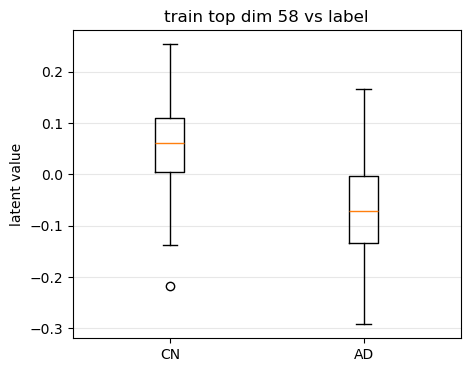

test top dims by |corr|/auc:
  dim  58 | corr=-0.7022 | auc= 0.0777
  dim  35 | corr= 0.5555 | auc= 0.8303
  dim  42 | corr=-0.5358 | auc= 0.1614
  dim 188 | corr= 0.5224 | auc= 0.8205
  dim  60 | corr= 0.4401 | auc= 0.7805


/tmp/ipykernel_80896/440176189.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[y == 0, top_dim], X[y == 1, top_dim]], labels=['CN', 'AD'])


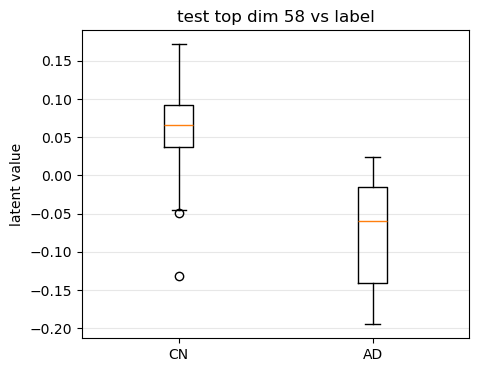

PCA component-label relation (train/test):
  comp 0: train corr= 0.4056 auc= 0.7395 | test corr= 0.2188 auc= 0.6644
  comp 1: train corr=-0.3412 auc= 0.3037 | test corr=-0.5821 auc= 0.1410
  comp 2: train corr= 0.3915 auc= 0.7257 | test corr= 0.4200 auc= 0.7459
  comp 3: train corr= 0.0274 auc= 0.5163 | test corr=-0.0815 auc= 0.4404
  comp 4: train corr= 0.0885 auc= 0.5377 | test corr=-0.2266 auc= 0.3537
ICA component-label relation (train/test):
  comp 0: train corr=-0.0086 auc= 0.4989 | test corr=-0.2209 auc= 0.3816
  comp 1: train corr= 0.2146 auc= 0.6213 | test corr=-0.1537 auc= 0.4306
  comp 2: train corr=-0.0191 auc= 0.4926 | test corr=-0.1388 auc= 0.4148
  comp 3: train corr= 0.0334 auc= 0.5159 | test corr= 0.1157 auc= 0.5784
  comp 4: train corr=-0.2251 auc= 0.3716 | test corr=-0.2497 auc= 0.3318


/home/jakaria/anaconda3/envs/inr_sdf/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA, FastICA

if 'train_latents' not in globals() or 'test_latents' not in globals():
    raise RuntimeError('Run the latent comparison cell first to load latents/labels.')

def _valid_mask(labels):
    return np.isfinite(labels) & (labels != -1)

def _score_dims(latents, labels, split_name, top_k=5):
    mask = _valid_mask(labels)
    if mask.sum() < 2:
        print(f'{split_name}: insufficient labels for analysis')
        return None
    y = labels[mask].astype(int)
    if len(np.unique(y)) < 2:
        print(f'{split_name}: only one class present')
        return None
    X = latents[mask]
    rows = []
    for d in range(X.shape[1]):
        v = X[:, d]
        if np.std(v) == 0:
            corr = float('nan')
            auc = float('nan')
        else:
            corr = float(np.corrcoef(v, y)[0, 1])
            try:
                auc = float(roc_auc_score(y, v))
            except ValueError:
                auc = float('nan')
        rows.append((d, corr, auc))
    rows_sorted = sorted(
        rows,
        key=lambda r: (abs(np.nan_to_num(r[1], nan=0.0)), np.nan_to_num(r[2], nan=0.0)),
        reverse=True,
    )
    print(f'{split_name} top dims by |corr|/auc:')
    for d, corr, auc in rows_sorted[:top_k]:
        print(f'  dim {d:3d} | corr={corr: .4f} | auc={auc: .4f}')
    return rows_sorted

def _plot_top_dim(latents, labels, rows_sorted, split_name):
    if not rows_sorted:
        return
    top_dim = rows_sorted[0][0]
    mask = _valid_mask(labels)
    y = labels[mask].astype(int)
    X = latents[mask]
    plt.figure(figsize=(5, 4))
    plt.boxplot([X[y == 0, top_dim], X[y == 1, top_dim]], labels=['CN', 'AD'])
    plt.title(f'{split_name} top dim {top_dim} vs label')
    plt.ylabel('latent value')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

train_rows = _score_dims(train_latents, train_labels, 'train')
_plot_top_dim(train_latents, train_labels, train_rows, 'train')
test_rows = _score_dims(test_latents, test_labels, 'test')
_plot_top_dim(test_latents, test_labels, test_rows, 'test')

# PCA/ICA components vs labels (fit on train, apply to test)
train_mask = _valid_mask(train_labels)
test_mask = _valid_mask(test_labels)
if train_mask.sum() >= 2 and test_mask.sum() >= 2:
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(train_latents[train_mask])
    Xte = scaler.transform(test_latents[test_mask])
    ytr = train_labels[train_mask].astype(int)
    yte = test_labels[test_mask].astype(int)

    def _report_components(Xtr, ytr, Xte, yte, name, transformer):
        comps_tr = transformer.fit_transform(Xtr)
        comps_te = transformer.transform(Xte)
        print(f'{name} component-label relation (train/test):')
        for idx in range(min(5, comps_tr.shape[1])):
            c_tr = comps_tr[:, idx]
            c_te = comps_te[:, idx]
            corr_tr = float(np.corrcoef(c_tr, ytr)[0, 1]) if np.std(c_tr) > 0 else float('nan')
            corr_te = float(np.corrcoef(c_te, yte)[0, 1]) if np.std(c_te) > 0 else float('nan')
            try:
                auc_tr = float(roc_auc_score(ytr, c_tr))
            except ValueError:
                auc_tr = float('nan')
            try:
                auc_te = float(roc_auc_score(yte, c_te))
            except ValueError:
                auc_te = float('nan')
            print(f'  comp {idx}: train corr={corr_tr: .4f} auc={auc_tr: .4f} | test corr={corr_te: .4f} auc={auc_te: .4f}')

    _report_components(Xtr, ytr, Xte, yte, 'PCA', PCA(n_components=min(10, Xtr.shape[1])))
    _report_components(Xtr, ytr, Xte, yte, 'ICA', FastICA(n_components=min(10, Xtr.shape[1]), random_state=0))
else:
    print('Skipping PCA/ICA component analysis: insufficient labels in train/test.')


KMeans purity: 0.6623376623376623
GMM purity: 0.6623376623376623
KMeans cluster counts: {0: {'CN': 23, 'AD': 3}, 1: {'CN': 28, 'AD': 23}}
GMM cluster counts: {0: {'CN': 12, 'AD': 0}, 1: {'CN': 39, 'AD': 26}}


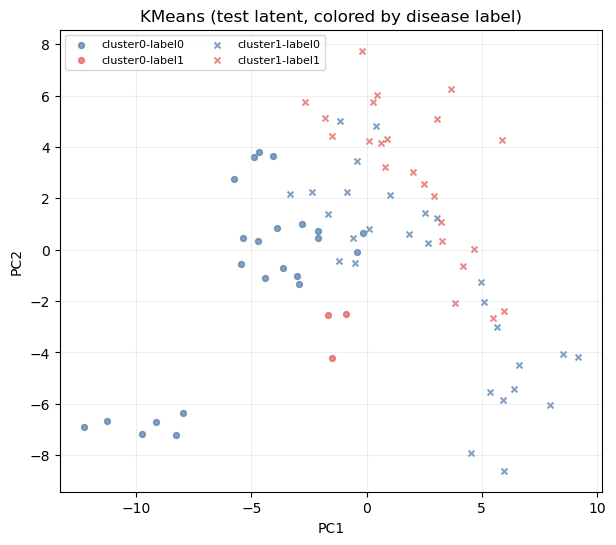

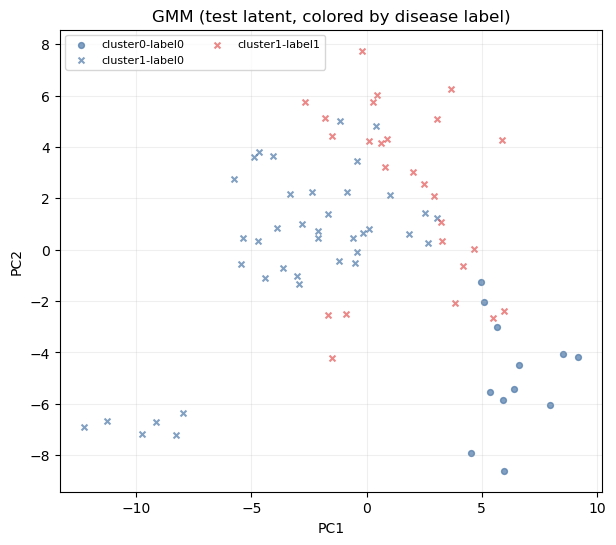

/tmp/ipykernel_80896/4179172966.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([vols_c0, vols_c1], labels=['cluster0', 'cluster1'], showmeans=True)


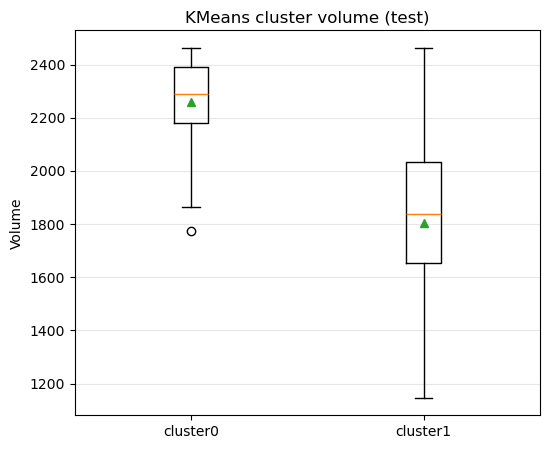

/tmp/ipykernel_80896/4179172966.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([vols_c0, vols_c1], labels=['cluster0', 'cluster1'], showmeans=True)


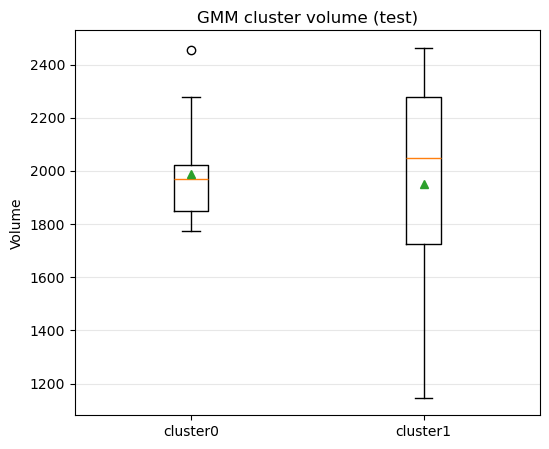

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

if 'test_latents' not in globals() or 'test_labels' not in globals():
    raise RuntimeError('Run the latent comparison cell first.')
if 'test_names' not in globals() or 'label_map' not in globals():
    raise RuntimeError('Missing test_names/label_map; re-run latent loading cell.')

volume_index = 3

def _collect_volume(names, label_map, index):
    vols = []
    for name in names:
        lbl = label_map.get(name)
        if lbl is None:
            vols.append(float('nan'))
            continue
        if isinstance(lbl, np.ndarray):
            arr = lbl
        else:
            try:
                arr = lbl.detach().cpu().numpy()
            except Exception:
                arr = np.array(lbl)
        if index >= arr.shape[0]:
            vols.append(float('nan'))
        else:
            vols.append(float(arr[index]))
    return np.array(vols, dtype=float)

test_volumes = _collect_volume(test_names, label_map, volume_index)
valid_mask = np.isfinite(test_labels) & (test_labels != -1) & np.isfinite(test_volumes)

X = test_latents[valid_mask]
y = test_labels[valid_mask].astype(int)
vols = test_volumes[valid_mask]

if X.shape[0] < 2:
    raise RuntimeError('Not enough valid test samples for clustering.')

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
km_labels = kmeans.fit_predict(Xz)

gmm = GaussianMixture(n_components=2, random_state=0)
gmm_labels = gmm.fit_predict(Xz)

def _purity(assignments, labels):
    purity_sum = 0
    total = len(labels)
    for c in np.unique(assignments):
        mask = assignments == c
        if mask.sum() == 0:
            continue
        counts = np.bincount(labels[mask])
        purity_sum += counts.max()
    return purity_sum / total if total > 0 else float('nan')

print('KMeans purity:', _purity(km_labels, y))
print('GMM purity:', _purity(gmm_labels, y))

def _cluster_counts(assignments, labels):
    counts = {}
    for c in np.unique(assignments):
        mask = assignments == c
        lbls = labels[mask]
        cn = int(np.sum(lbls == 0))
        ad = int(np.sum(lbls == 1))
        counts[int(c)] = {'CN': cn, 'AD': ad}
    return counts

print('KMeans cluster counts:', _cluster_counts(km_labels, y))
print('GMM cluster counts:', _cluster_counts(gmm_labels, y))

pca = PCA(n_components=2)
X2 = pca.fit_transform(Xz)

def _plot_clusters(assignments, title):
    plt.figure(figsize=(7, 6))
    for c in [0, 1]:
        mask_c = assignments == c
        for lbl, color in [(0, '#4C78A8'), (1, '#E45756')]:
            mask = mask_c & (y == lbl)
            if mask.any():
                marker = 'o' if c == 0 else 'x'
                plt.scatter(X2[mask, 0], X2[mask, 1], s=18, alpha=0.7, c=color, marker=marker, label=f'cluster{c}-label{lbl}')
    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.2)
    plt.show()

_plot_clusters(km_labels, 'KMeans (test latent, colored by disease label)')
_plot_clusters(gmm_labels, 'GMM (test latent, colored by disease label)')

def _boxplot_volumes(assignments, title):
    vols_c0 = vols[assignments == 0]
    vols_c1 = vols[assignments == 1]
    plt.figure(figsize=(6, 5))
    plt.boxplot([vols_c0, vols_c1], labels=['cluster0', 'cluster1'], showmeans=True)
    plt.ylabel('Volume')
    plt.title(title)
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

_boxplot_volumes(km_labels, 'KMeans cluster volume (test)')
_boxplot_volumes(gmm_labels, 'GMM cluster volume (test)')
